## E-commerce Search Project — Notebook Guide

This notebook is organized as a phased retrieval pipeline so the reviewer can quickly separate core project work from advanced extensions.

### Reading Order
1. **Setup + Data Loading** — reproducible dataset and preprocessing setup.
2. **Phase A (Primary / Core Retrieval Track)** — lexical retrieval improvements that increase MAP@10 above baseline.
3. **Phase B (Extension)** — hybrid lexical + semantic retrieval.
4. **Phase C (Extension)** — two-stage re-ranking for precision at top ranks.
5. **Phase D (Optional/API-dependent)** — LLM-based query expansion.
6. **Prompt 2 Metric Upgrade** — fairer evaluation with NDCG@10 using partial matches.
7. **Conclusions** — final results, tradeoffs, and next steps.

### Reproducibility Notes
- Core results (Phases A-C + Prompt 2) run locally without proprietary code.
- Phase D requires external API/model downloads and is clearly marked as optional.
- API keys are read from `.env` and should be removed/obfuscated before sharing.


## Introduction

This notebook presents my solution to the ecommerce search project on the WANDS dataset. The primary objective is to improve retrieval quality over the TF-IDF baseline (MAP@10 ~0.29), while keeping the workflow reproducible and easy to evaluate.

I organize the work into phases: **Phase A** (core lexical improvements, primary objective), **Phase B** (hybrid retrieval), and **Phase C** (re-ranking), with an optional **Phase D** for LLM-based query expansion. In parallel, I also apply engineering-track principles by using a modular, object-oriented code structure.


In [1]:
import logging
import os
import sys
from pathlib import Path

# --- Quiet mode: reduce notebook log/progress noise ---
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
os.environ.setdefault("TQDM_DISABLE", "1")

import pandas as pd
import numpy as np


def _safe_cwd() -> Path:
    """Return a valid cwd even if the original working dir was removed."""
    try:
        return Path.cwd().resolve()
    except FileNotFoundError:
        pwd = os.environ.get("PWD")
        if pwd:
            try:
                return Path(pwd).expanduser().resolve()
            except Exception:
                pass
        return Path.home().resolve()


# Make src/ importable when running from notebooks/ or repo root,
# and robust to kernels with stale/removed working directories.
cwd = _safe_cwd()
PROJECT_ROOT = next(
    (p for p in (cwd, *cwd.parents) if (p / "src" / "ecom_search").exists()),
    cwd,
)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from ecom_search.data_loader import WANDSDataLoader
from ecom_search.search_engine import (
    TfidfSearchEngine, BM25SearchEngine, WeightedTfidfSearchEngine,
    SentenceTransformerSearchEngine, HybridSearchEngine,
    ReRankingEngine, CrossEncoderReranker, MetadataBoostReranker,
    QueryExpandedSearchEngine,
)
from ecom_search.evaluation import Evaluator
from ecom_search.preprocessing import preprocess_text, parse_product_features, make_preprocessor
from ecom_search.query_processor import LLMQueryExpander, LLMIntentExpander

# Keep notebook output concise by default
logging.basicConfig(level=logging.WARNING, format="%(name)s — %(message)s")

# Force noisy libraries to ERROR
for name in [
    "ecom_search",
    "sentence_transformers",
    "sentence_transformers.cross_encoder.CrossEncoder",
    "transformers",
    "httpx",
    "httpcore",
    "huggingface_hub",
    "huggingface_hub.utils._http",
]:
    logging.getLogger(name).setLevel(logging.ERROR)

# Library-level verbosity controls (best effort)
try:
    from huggingface_hub.utils import disable_progress_bars
    disable_progress_bars()
except Exception:
    pass

try:
    from transformers import logging as transformers_logging
    transformers_logging.set_verbosity_error()
except Exception:
    pass


In [2]:
# Clone the WANDS dataset if not already present
loader = WANDSDataLoader()
loader.ensure_data()

ecom_search.data_loader — WANDS repo already exists at /Users/tiagobachiegadealmeida/Projects/ecommerce-search-engine/WANDS


In [3]:
# Load all datasets via the data loader (cached after first call)
product_df = loader.load_products()
query_df = loader.load_queries()
label_df = loader.load_labels()

ecom_search.data_loader — Loaded product.csv: 42994 rows, 9 columns
ecom_search.data_loader — Loaded query.csv: 480 rows, 3 columns
ecom_search.data_loader — Loaded label.csv: 233448 rows, 4 columns


In [4]:
product_df.head()

,product_id,product_name,product_class,category hierarchy,product_description,product_features,rating_count,average_rating,review_count
0,0,solid wood platform bed,Beds,Furniture / Bedroom Furniture / Beds & Headboa...,"good , deep sleep can be quite difficult to ha...",overallwidth-sidetoside:64.7|dsprimaryproducts...,15.0,4.5,15.0
1,1,all-clad 7 qt . slow cooker,Slow Cookers,Kitchen & Tabletop / Small Kitchen Appliances ...,"create delicious slow-cooked meals , from tend...",capacityquarts:7|producttype : slow cooker|pro...,100.0,2.0,98.0
2,2,all-clad electrics 6.5 qt . slow cooker,Slow Cookers,Kitchen & Tabletop / Small Kitchen Appliances ...,prepare home-cooked meals on any schedule with...,features : keep warm setting|capacityquarts:6....,208.0,3.0,181.0
3,3,all-clad all professional tools pizza cutter,"Slicers, Peelers And Graters",Browse By Brand / All-Clad,this original stainless tool was designed to c...,overallwidth-sidetoside:3.5|warrantylength : l...,69.0,4.5,42.0
4,4,baldwin prestige alcott passage knob with roun...,Door Knobs,Home Improvement / Doors & Door Hardware / Doo...,the hardware has a rich heritage of delivering...,compatibledoorthickness:1.375 '' |countryofori...,70.0,5.0,42.0


In [5]:
query_df.head()

,query_id,query,query_class
0,0,salon chair,Massage Chairs
1,1,smart coffee table,Coffee & Cocktail Tables
2,2,dinosaur,Kids Wall Décor
3,3,turquoise pillows,Accent Pillows
4,4,chair and a half recliner,Recliners


In [6]:
label_df.head()

,id,query_id,product_id,label
0,0,0,25434,Exact
1,1,0,12088,Irrelevant
2,2,0,42931,Exact
3,3,0,2636,Exact
4,4,0,42923,Exact


In [7]:
# Parse product_features into clean text and add as a new column (A2)
product_df["parsed_features"] = product_df["product_features"].apply(parse_product_features)
print("Sample parsed features:")
print(product_df["parsed_features"].iloc[0][:200])

Sample parsed features:
overallwidth sidetoside 64.7 dsprimaryproductstyle modern countryoforigin additionaldetails made in viet nam headboardtype slat headboardheight toptobedframe 25.35 weightcapacity 500 estimatedtimetose


## Prompt 1: Proposed Improvements to Increase MAP@10

**Project framing:** I prioritized the **core retrieval-improvement track** as the primary objective (implementing retrieval improvements and demonstrating MAP gains), and I also completed substantial **engineering-track** refactoring work for code quality and production readiness.

The baseline TF-IDF search engine achieves a MAP@10 of ~0.29. Below are several ideas to improve retrieval quality, ordered roughly by implementation effort:

### 1. BM25 over TF-IDF
BM25 (Best Matching 25) improves on raw TF-IDF by introducing **term frequency saturation** (parameter `k1`) and **document length normalization** (parameter `b`). Long product descriptions won't unfairly dominate shorter, more precise ones.
- **Pros**: Well-understood, fast, no training needed, drop-in replacement.
- **Cons**: Still lexical — no semantic understanding ("sofa" won't match "couch").
- **References**: Robertson & Zaragoza, "The Probabilistic Relevance Framework: BM25 and Beyond" (2009).

### 2. Richer Text Representation
The baseline only indexes `product_name + product_description`. The WANDS dataset also provides:
- `product_class` — category the product belongs to
- `category_hierarchy` — parent categories (e.g. "Furniture / Living Room / Seating")
- `product_features` — attribute:value pairs (e.g. "Material:Leather|Color:Brown")

Including these fields adds **category-level matching** and **attribute signals**.
- **Pros**: Easy win, uses already-available data, no new dependencies.
- **Cons**: Noisy features (especially long `product_features` strings) may hurt precision.

### 3. Text Preprocessing
Add stemming/lemmatization, stop word removal, and text normalization before indexing.
- **Pros**: Reduces vocabulary mismatch (e.g., "chairs" → "chair").
- **Cons**: Can lose important distinctions; adds preprocessing complexity.

### 4. Semantic Embeddings (sentence-transformers)
Models like `all-MiniLM-L6-v2` encode text into dense vectors that capture meaning beyond exact word overlap. "Sofa" and "couch" end up near each other in embedding space.
- **Pros**: Handles synonyms, paraphrasing, and conceptual similarity.
- **Cons**: Compute-heavy for 42K products (~2-5 min on CPU), requires model download (~80 MB).
- **References**: Reimers & Gurevych, "Sentence-BERT" (EMNLP 2019).

### 5. Hybrid Retrieval (BM25 + Semantic)
Combine BM25 (precise lexical matching) with dense embeddings (broad semantic recall) using **reciprocal rank fusion** or **weighted score fusion**. This is the approach used by modern production search systems (e.g., Elasticsearch with vector search).
- **Pros**: Best of both worlds; state-of-the-art in information retrieval.
- **Cons**: More complexity, needs weight tuning, slower inference.

### 6. Query Expansion
Use the `query_class` field from query.csv to expand query terms with category context.
- **Pros**: Adds domain signal when queries are ambiguous.
- **Cons**: Can introduce noise if category mapping is imprecise.

### 7. Learning-to-Rank Re-ranking
Use product metadata (`average_rating`, `review_count`, `rating_count`) as features in a second-stage re-ranker over the top-K candidates from a first-stage retrieval model.
- **Pros**: Personalizes ranking with popularity signals, standard in production search.
- **Cons**: Overfitting risk with limited query set (480 queries); needs train/test split.

## Architecture Track (Engineering Refactor Applied Across All Phases)

Although the official project focus is the **core retrieval-improvement track**, the implementation uses engineering-track principles end-to-end so each phase reuses the same modular, object-oriented components.

The code has been refactored into separate Python modules for production readiness:

- **`data_loader.py`** — `WANDSDataLoader` class: handles cloning, CSV loading, caching, error handling, and logging.
- **`search_engine.py`** — `SearchEngine` ABC with three implementations:
  - `TfidfSearchEngine` — configurable TF-IDF + cosine similarity
  - `BM25SearchEngine` — BM25Okapi with configurable tokenizer
  - `SentenceTransformerSearchEngine` — dense semantic search (any HF model)
- **`evaluation.py`** — `Evaluator` class with `map_at_k()`, `ndcg_at_k()`, and `evaluate_queries()`.

All engines share the same `fit()` / `search()` interface, so swapping backends is a one-line change. Below we instantiate and compare several configurations.

## Phase A: Lexical Retrieval Improvements (Primary Deliverable)

**Goal:** Improve baseline TF-IDF MAP@10 (~0.29) using practical, reproducible lexical techniques.

**Changes implemented in this phase:**
- BM25 retriever and stronger token matching behavior
- Richer document fields (`product_class`, `category_hierarchy`, parsed `product_features`)
- Text normalization with stemming + synonym handling

**Success criterion for Phase A:** Demonstrate a clear MAP@10 lift over baseline and exceed 0.30.


In [8]:
# Build preprocessor (A1: stemming + A5: synonyms)
preprocessor = make_preprocessor(stem=True, synonyms=True)

# Column sets
baseline_cols = ["product_name", "product_description"]
enriched_cols = ["product_name", "product_description", "product_class", "category hierarchy"]
full_cols     = ["product_name", "product_description", "product_class", "category hierarchy", "parsed_features"]

engines = [
    # ── Original baselines ──
    TfidfSearchEngine(columns=baseline_cols, name_override="TF-IDF baseline"),
    BM25SearchEngine(columns=baseline_cols, name_override="BM25 baseline"),
    BM25SearchEngine(columns=enriched_cols, name_override="BM25 enriched"),

    # ── A1+A5: Preprocessing (stemming + synonyms) ──
    BM25SearchEngine(columns=enriched_cols, preprocessor=preprocessor,
                     name_override="BM25 enriched + stem/syn"),

    # ── A2: Parsed product features ──
    BM25SearchEngine(columns=full_cols, preprocessor=preprocessor,
                     name_override="BM25 full + stem/syn"),

    # ── A3: Field weighting ──
    WeightedTfidfSearchEngine(
        column_weights={
            "product_name": 3.0,
            "product_class": 2.0,
            "category hierarchy": 1.5,
            "product_description": 1.0,
        },
        preprocessor=preprocessor,
        name_override="Weighted TF-IDF + stem/syn",
    ),

    # ── A4: Word bigrams ──
    TfidfSearchEngine(
        columns=enriched_cols,
        vectorizer_kwargs={"ngram_range": (1, 2), "max_features": 200_000},
        preprocessor=preprocessor,
        name_override="TF-IDF bigrams + stem/syn",
    ),

    # ── A4: Character n-grams ──
    TfidfSearchEngine(
        columns=enriched_cols,
        vectorizer_kwargs={"analyzer": "char_wb", "ngram_range": (3, 5), "max_features": 300_000},
        preprocessor=preprocessor,
        name_override="TF-IDF char-ngrams + stem/syn",
    ),
]

# Fit all engines on the product catalogue
for engine in engines:
    engine.fit(product_df)

ecom_search.search_engine — TF-IDF baseline — indexed 42994 documents, vocabulary size 46589
ecom_search.search_engine — BM25 baseline — indexed 42994 documents
ecom_search.search_engine — BM25 enriched — indexed 42994 documents
ecom_search.search_engine — BM25 enriched + stem/syn — indexed 42994 documents
ecom_search.search_engine — BM25 full + stem/syn — indexed 42994 documents
ecom_search.search_engine — Weighted TF-IDF + stem/syn — indexed 42994 documents across 4 fields
ecom_search.search_engine — TF-IDF bigrams + stem/syn — indexed 42994 documents, vocabulary size 200000
ecom_search.search_engine — TF-IDF char-ngrams + stem/syn — indexed 42994 documents, vocabulary size 166498


In [9]:
# Sanity check: compare top-10 results for "armchair" across engines
test_query = "armchair"

for engine in engines:
    indices = engine.search(test_query, top_n=10)
    ids = product_df.iloc[indices]["product_id"].tolist()
    names = product_df.iloc[indices]["product_name"].tolist()
    print(f"\n{'='*60}")
    print(f"{engine.name} — Top products for '{test_query}':")
    for pid, name in zip(ids, names):
        print(f"  {pid}: {name}")


TF-IDF baseline — Top products for 'armchair':
  40705: 28.5 '' wide armchair
  40707: 33 '' wide armchair
  27998: 21 '' wide armchair
  12756: 24.41 '' wide tufted polyester armchair
  42698: donham armchair
  14172: 24 '' wide velvet armchair
  15687: 29 '' wide polyester armchair
  14168: 18.5 '' wide velvet armchair
  42697: donham 25 '' wide armchair
  14166: 29.5 '' wide velvet armchair

BM25 baseline — Top products for 'armchair':
  12756: 24.41 '' wide tufted polyester armchair
  42697: donham 25 '' wide armchair
  1140: charnley 47 '' wide chenille armchair
  34983: langsett 30 '' wide armchair
  1527: howington 39 '' wide tufted linen armchair
  6532: ogan 29 '' wide polyester armchair
  42698: donham armchair
  1141: colinton 41 '' wide chenille armchair
  41270: almaraz 33.7 '' wide leather match armchair
  23927: catania 30 '' wide polyester armchair

BM25 enriched — Top products for 'armchair':
  12756: 24.41 '' wide tufted polyester armchair
  42697: donham 25 '' wide 

## Phase A Results: MAP@10 and NDCG@10 Comparison

We evaluate each engine configuration using:
- **MAP@10** (binary, Exact-only) — for backward compatibility with the original baseline metric.
- **NDCG@10** (graded: Exact=2, Partial=1, Irrelevant=0) — a fairer metric that credits partial matches (see Prompt 2 discussion below).

**How to interpret this table:**
- MAP@10 is the official baseline metric for prompt 1 progression.
- NDCG@10 is included as a graded relevance view (Prompt 2), but Phase A comparisons still emphasize MAP lift.


In [10]:
# Evaluate all engines and collect summary metrics
summary_rows = []

for engine in engines:
    result_df = Evaluator.evaluate_queries(
        engine=engine,
        product_df=product_df,
        query_df=query_df,
        label_df=label_df,
        k=10,
    )
    summary_rows.append({
        "Engine": engine.name,
        "MAP@10": round(result_df["map@k"].mean(), 4),
        "NDCG@10": round(result_df["ndcg@k"].mean(), 4),
    })
    
summary_df = pd.DataFrame(summary_rows)
summary_df

ecom_search.evaluation — TF-IDF baseline — MAP@10: 0.2855 | NDCG@10: 0.6196
ecom_search.evaluation — BM25 baseline — MAP@10: 0.3651 | NDCG@10: 0.6649
ecom_search.evaluation — BM25 enriched — MAP@10: 0.3839 | NDCG@10: 0.6801
ecom_search.evaluation — BM25 enriched + stem/syn — MAP@10: 0.4105 | NDCG@10: 0.7088
ecom_search.evaluation — BM25 full + stem/syn — MAP@10: 0.4146 | NDCG@10: 0.6895
ecom_search.evaluation — Weighted TF-IDF + stem/syn — MAP@10: 0.3380 | NDCG@10: 0.6710
ecom_search.evaluation — TF-IDF bigrams + stem/syn — MAP@10: 0.2983 | NDCG@10: 0.6771
ecom_search.evaluation — TF-IDF char-ngrams + stem/syn — MAP@10: 0.3319 | NDCG@10: 0.6718


,Engine,MAP@10,NDCG@10
0,TF-IDF baseline,0.2855,0.6196
1,BM25 baseline,0.3651,0.6649
2,BM25 enriched,0.3839,0.6801
3,BM25 enriched + stem/syn,0.4105,0.7088
4,BM25 full + stem/syn,0.4146,0.6895
5,Weighted TF-IDF + stem/syn,0.3380,0.6710
6,TF-IDF bigrams + stem/syn,0.2983,0.6771
7,TF-IDF char-ngrams + stem/syn,0.3319,0.6718


<Axes: title={'center': 'Search Engine Comparison — MAP@10 vs NDCG@10'}, ylabel='Engine'>

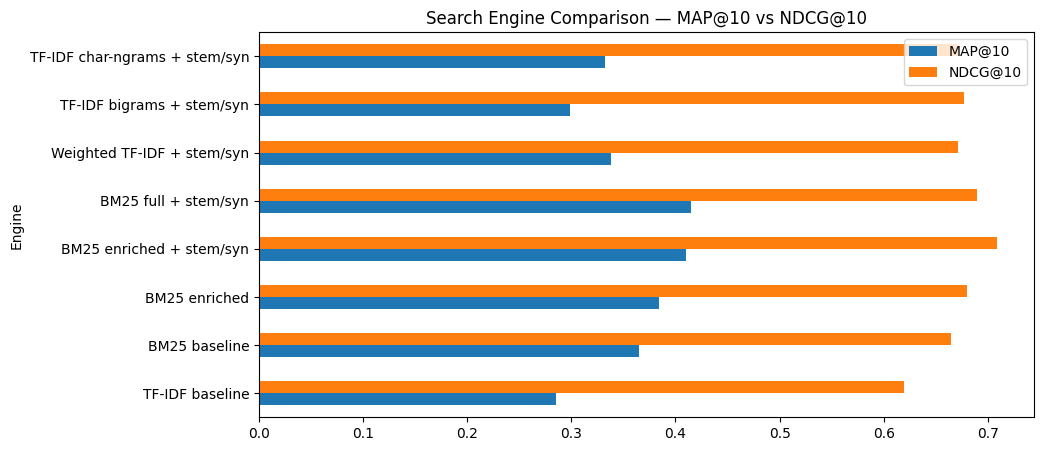

In [11]:
# Visualize the comparison
summary_df.set_index("Engine")[["MAP@10", "NDCG@10"]].plot(
    kind="barh", figsize=(10, 5), title="Search Engine Comparison — MAP@10 vs NDCG@10"
)

In [12]:
import gc

# Keep only engines used later: TF-IDF baseline and best lexical
tfidf_baseline = engines[0]
best_lexical = engines[3]  # "BM25 enriched + stem/syn"
del engines
gc.collect()
print(f"Phase A cleanup — freed unused engines, gc collected {gc.collect()} objects")

Phase A cleanup — freed unused engines, gc collected 0 objects


## Phase B: Hybrid Lexical + Semantic Retrieval

The best lexical engine so far is **BM25 enriched + stem/syn** (MAP@10 ≈ 0.41). Lexical models cannot handle synonymy or paraphrasing — "sofa" and "couch" share no tokens.

**Approach:** encode products with a sentence-transformer (`all-MiniLM-L6-v2`), then fuse BM25 scores with cosine-similarity scores via:

1. **Weighted fusion** — `final = α × BM25_norm + (1 − α) × semantic_norm` (min-max normalised)
2. **Reciprocal Rank Fusion (RRF)** — parameter-free: `score = Σ 1/(k + rank)` from each list

Both retrieve top-100 from each engine before fusion, then return the top-10.

**Scope note:** Phase B is an extension beyond the core project requirement. It explores additional gains after Phase A is already successful.

**Phase objective:** improve recall/semantic matching while keeping strong lexical precision from Phase A.


In [13]:
# B1: Fit SentenceTransformer engine (≈2-5 min on CPU)
semantic_engine = SentenceTransformerSearchEngine(
    model_name="all-MiniLM-L6-v2",
    columns=enriched_cols,
)
semantic_engine.fit(product_df) 

# best_lexical already set during Phase A cleanup

# B2: Build hybrid engines
hybrid_weighted = HybridSearchEngine(
    engine_a=best_lexical,
    engine_b=semantic_engine,
    alpha=0.5,
    strategy="weighted",
    name_override="Hybrid BM25+Semantic (α=0.5)",
)
hybrid_weighted.fit(product_df)

hybrid_rrf = HybridSearchEngine(
    engine_a=best_lexical,
    engine_b=semantic_engine,
    strategy="rrf",
    name_override="Hybrid BM25+Semantic (RRF)",
)
hybrid_rrf.fit(product_df)

/Users/tiagobachiegadealmeida/Projects/ecommerce-search-engine/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
sentence_transformers.SentenceTransformer — Use pytorch device_name: mps
sentence_transformers.SentenceTransformer — Load pretrained SentenceTransformer: all-MiniLM-L6-v2
httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
huggingface_hub.utils._http — Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
httpx — HTTP Request: H

In [14]:
# Evaluate Phase B engines alongside baselines for comparison
phase_b_engines = [
    tfidf_baseline,      # TF-IDF baseline
    best_lexical,        # BM25 enriched + stem/syn (best Phase A)
    semantic_engine,     # Pure semantic
    hybrid_weighted,     # Weighted fusion α=0.5
    hybrid_rrf,          # RRF fusion
]

phase_b_rows = []
for eng in phase_b_engines:
    rdf = Evaluator.evaluate_queries(
        engine=eng, product_df=product_df,
        query_df=query_df, label_df=label_df, k=10,
    )
    phase_b_rows.append({
        "Engine": eng.name,
        "MAP@10": round(rdf["map@k"].mean(), 4),
        "NDCG@10": round(rdf["ndcg@k"].mean(), 4),
    })

phase_b_df = pd.DataFrame(phase_b_rows)
phase_b_df

ecom_search.evaluation — TF-IDF baseline — MAP@10: 0.2855 | NDCG@10: 0.6196
ecom_search.evaluation — BM25 enriched + stem/syn — MAP@10: 0.4105 | NDCG@10: 0.7088
ecom_search.evaluation — SentenceTransformer (all-MiniLM-L6-v2) — MAP@10: 0.3800 | NDCG@10: 0.7015
ecom_search.evaluation — Hybrid BM25+Semantic (α=0.5) — MAP@10: 0.4413 | NDCG@10: 0.7472
ecom_search.evaluation — Hybrid BM25+Semantic (RRF) — MAP@10: 0.4322 | NDCG@10: 0.7538


,Engine,MAP@10,NDCG@10
0,TF-IDF baseline,0.2855,0.6196
1,BM25 enriched + stem/syn,0.4105,0.7088
2,SentenceTransformer (all-MiniLM-L6-v2),0.3800,0.7015
3,Hybrid BM25+Semantic (α=0.5),0.4413,0.7472
4,Hybrid BM25+Semantic (RRF),0.4322,0.7538


ecom_search.search_engine — Hybrid(BM25 enriched + stem/syn + SentenceTransformer (all-MiniLM-L6-v2), α=0.0, weighted) — using pre-fitted sub-engines
ecom_search.evaluation — Hybrid(BM25 enriched + stem/syn + SentenceTransformer (all-MiniLM-L6-v2), α=0.0, weighted) — MAP@10: 0.3800 | NDCG@10: 0.7015
ecom_search.search_engine — Hybrid(BM25 enriched + stem/syn + SentenceTransformer (all-MiniLM-L6-v2), α=0.1, weighted) — using pre-fitted sub-engines
ecom_search.evaluation — Hybrid(BM25 enriched + stem/syn + SentenceTransformer (all-MiniLM-L6-v2), α=0.1, weighted) — MAP@10: 0.3910 | NDCG@10: 0.7104
ecom_search.search_engine — Hybrid(BM25 enriched + stem/syn + SentenceTransformer (all-MiniLM-L6-v2), α=0.2, weighted) — using pre-fitted sub-engines
ecom_search.evaluation — Hybrid(BM25 enriched + stem/syn + SentenceTransformer (all-MiniLM-L6-v2), α=0.2, weighted) — MAP@10: 0.4023 | NDCG@10: 0.7199
ecom_search.search_engine — Hybrid(BM25 enriched + stem/syn + SentenceTransformer (all-MiniLM-L6-

Best α = 0.6  →  MAP@10 = 0.4429, NDCG@10 = 0.7424


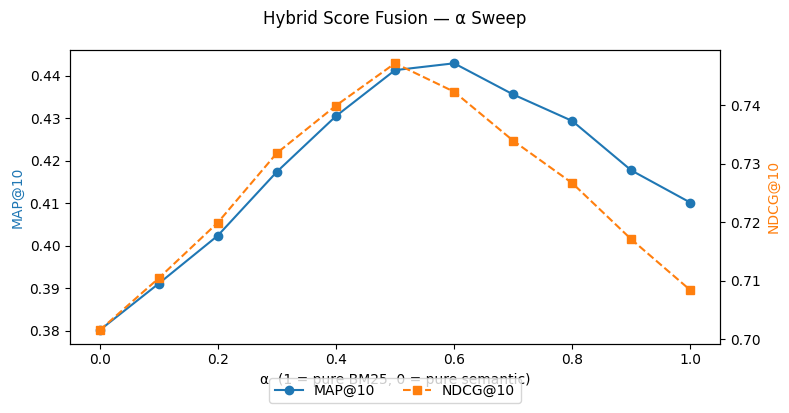

In [15]:
# B3: Alpha tuning — sweep α to find the optimal BM25/semantic blend
import matplotlib.pyplot as plt

alphas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
alpha_map = []
alpha_ndcg = []

for a in alphas:
    h = HybridSearchEngine(
        engine_a=best_lexical, engine_b=semantic_engine,
        alpha=a, strategy="weighted",
    )
    h.fit(product_df)
    rdf = Evaluator.evaluate_queries(
        engine=h, product_df=product_df,
        query_df=query_df, label_df=label_df, k=10,
    )
    alpha_map.append(rdf["map@k"].mean())
    alpha_ndcg.append(rdf["ndcg@k"].mean())

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(alphas, alpha_map, "o-", color="tab:blue", label="MAP@10")
ax1.set_xlabel("α  (1 = pure BM25, 0 = pure semantic)")
ax1.set_ylabel("MAP@10", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(alphas, alpha_ndcg, "s--", color="tab:orange", label="NDCG@10")
ax2.set_ylabel("NDCG@10", color="tab:orange")

fig.suptitle("Hybrid Score Fusion — α Sweep")
fig.legend(loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()

best_idx = max(range(len(alphas)), key=lambda i: alpha_map[i])
print(f"Best α = {alphas[best_idx]:.1f}  →  MAP@10 = {alpha_map[best_idx]:.4f}, NDCG@10 = {alpha_ndcg[best_idx]:.4f}")

## Phase C: Two-Stage Re-ranking

First-stage retrieval (BM25 or hybrid) is fast but coarse. A second-stage **re-ranker** can rescore the top-100 candidates with a richer signal:

1. **Cross-encoder re-ranking** — A cross-encoder (`cross-encoder/ms-marco-MiniLM-L-6-v2`) scores each `(query, document)` pair jointly, capturing fine-grained relevance that bi-encoder similarity misses.
2. **Metadata boost** — Product `average_rating` and `review_count` act as popularity/quality priors, breaking ties and boosting well-reviewed items.
3. **Combined** — Cross-encoder rescoring + metadata boost on the best first-stage retriever.

**Scope note:** Phase C is another extension layer focused on top-rank precision (`P@1`/early rank quality behavior), built on the best Phase B retriever.

**Phase objective:** keep retrieval recall from Phase B, then improve ordering quality in top-10.


In [16]:
# C1: Cross-encoder re-ranking on top of best hybrid (weighted α=0.5)
cross_encoder_reranker = CrossEncoderReranker(
    model_name="cross-encoder/ms-marco-MiniLM-L-6-v2",
    columns=enriched_cols,
)

rerank_hybrid_ce = ReRankingEngine(
    retriever=hybrid_weighted,
    reranker=cross_encoder_reranker,
    retrieve_n=100,
    name_override="Hybrid + CrossEncoder rerank",
)
rerank_hybrid_ce.fit(product_df)

# C2: Metadata boost on top of best hybrid
metadata_reranker = MetadataBoostReranker(beta=0.1, gamma=0.05)

rerank_hybrid_meta = ReRankingEngine(
    retriever=hybrid_weighted,
    reranker=metadata_reranker,
    retrieve_n=100,
    name_override="Hybrid + Metadata boost",
)
rerank_hybrid_meta.fit(product_df)

# C3: Cross-encoder on top of best lexical (BM25)
rerank_bm25_ce = ReRankingEngine(
    retriever=best_lexical,
    reranker=cross_encoder_reranker,
    retrieve_n=100,
    name_override="BM25 + CrossEncoder rerank",
)
rerank_bm25_ce.fit(product_df)

ecom_search.search_engine — Hybrid + CrossEncoder rerank — ready (retriever already fitted)
ecom_search.search_engine — Hybrid + Metadata boost — ready (retriever already fitted)
ecom_search.search_engine — BM25 + CrossEncoder rerank — ready (retriever already fitted)


In [17]:
# Evaluate Phase C engines alongside key baselines
phase_c_engines = [
    tfidf_baseline,      # TF-IDF baseline
    best_lexical,        # BM25 enriched + stem/syn
    hybrid_weighted,     # Best hybrid (Phase B)
    rerank_bm25_ce,      # BM25 + cross-encoder
    rerank_hybrid_ce,    # Hybrid + cross-encoder
    rerank_hybrid_meta,  # Hybrid + metadata boost
]

phase_c_rows = []
for eng in phase_c_engines:
    rdf = Evaluator.evaluate_queries(
        engine=eng, product_df=product_df,
        query_df=query_df, label_df=label_df, k=10,
    )
    phase_c_rows.append({
        "Engine": eng.name,
        "MAP@10": round(rdf["map@k"].mean(), 4),
        "NDCG@10": round(rdf["ndcg@k"].mean(), 4),
    })

phase_c_df = pd.DataFrame(phase_c_rows)
phase_c_df

ecom_search.evaluation — TF-IDF baseline — MAP@10: 0.2855 | NDCG@10: 0.6196
ecom_search.evaluation — BM25 enriched + stem/syn — MAP@10: 0.4105 | NDCG@10: 0.7088
ecom_search.evaluation — Hybrid BM25+Semantic (α=0.5) — MAP@10: 0.4413 | NDCG@10: 0.7472
httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cross-encoder/ms-marco-MiniLM-L6-v2/c5ee24cb16019beea0893ab7796b1df96625c6b8/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 8255.27it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_id

,Engine,MAP@10,NDCG@10
0,TF-IDF baseline,0.2855,0.6196
1,BM25 enriched + stem/syn,0.4105,0.7088
2,Hybrid BM25+Semantic (α=0.5),0.4413,0.7472
3,BM25 + CrossEncoder rerank,0.4668,0.7611
4,Hybrid + CrossEncoder rerank,0.4704,0.7630
5,Hybrid + Metadata boost,0.4415,0.7471


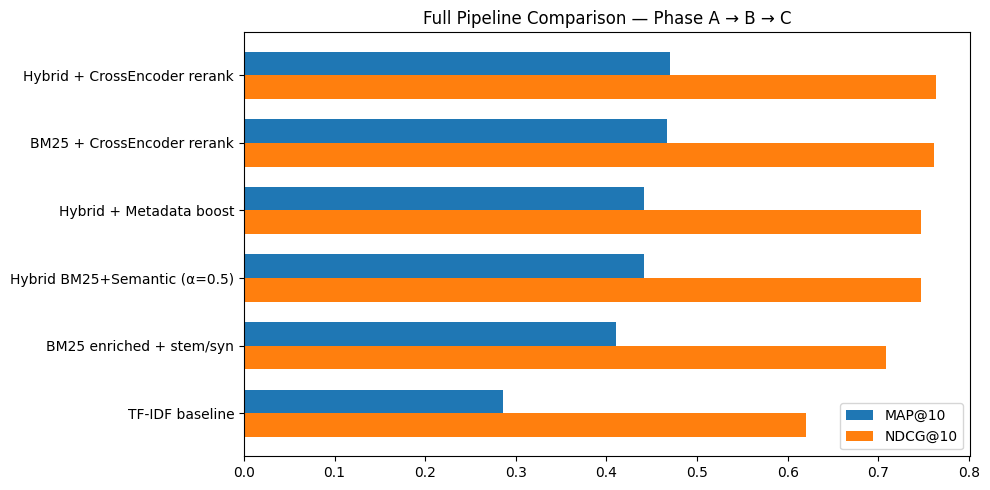

In [18]:
# Final comparison chart — all phases
import matplotlib.pyplot as plt

final_df = phase_c_df.sort_values("MAP@10")
y = range(len(final_df))
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(y, final_df["MAP@10"], height=0.35, label="MAP@10", align="edge")
ax.barh([i - 0.35 for i in y], final_df["NDCG@10"], height=0.35, label="NDCG@10", align="edge")
ax.set_yticks(y)
ax.set_yticklabels(final_df["Engine"])
ax.set_title("Full Pipeline Comparison — Phase A → B → C")
ax.legend()
plt.tight_layout()

In [19]:
# Free Phase C models before loading Flan-T5 — the CrossEncoder will lazy-reload in D3
cross_encoder_reranker.release_model()
del rerank_bm25_ce, rerank_hybrid_meta  # only rerank_hybrid_ce needed later
gc.collect()
print(f"Phase C cleanup — freed CrossEncoder + unused rerankers, gc collected {gc.collect()} objects")

Phase C cleanup — freed CrossEncoder + unused rerankers, gc collected 0 objects


## Phase D: LLM-Enhanced Query Understanding & Expansion

Lexical and semantic engines treat the raw query string as-is. But short, ambiguous queries (e.g. "salon chair") can benefit from **query expansion** — adding synonyms and category signals before retrieval.

We test two strategies using the **OpenAI GPT-4o-mini** API (cloud-based, zero local RAM):

1. **D1 — LLM synonym expansion**: generate product synonyms and related terms.
2. **D2 — LLM intent extraction**: extract structured attributes (category, material, colour, style) and append them.

Both use `QueryExpandedSearchEngine`, a thin wrapper that applies expansion before passing the query to any inner engine. Results are cached to `.cache/` so repeated runs don't call the API.

**Optional section:** This phase is intentionally separated because it depends on external APIs/downloads and is not required to validate the core project outcome.


In [20]:
# Create GPT-based expanders and pre-expand all queries (results cached to .cache/)
import os
# os.environ["OPENAI_API_KEY"] = "sk-..."  # uncomment & set if not already in env

llm_expander = LLMQueryExpander()
intent_expander = LLMIntentExpander()

print("Pre-expanding all queries with D1 (synonyms)…")
llm_expander.pre_expand(query_df["query"])
print(f"  cached {len(llm_expander._cache)} queries")

print("Pre-expanding all queries with D2 (intent)…")
intent_expander.pre_expand(query_df["query"])
print(f"  cached {len(intent_expander._cache)} queries")

# Preview a few expansions
for sample_q in ["salon chair", "turquoise pillows", "smart coffee table"]:
    print(f"\nD1 synonym: '{sample_q}' → '{llm_expander.expand(sample_q)}'")
    print(f"D2 intent:  '{sample_q}' → '{intent_expander.expand(sample_q)}'")

print("\nAll expansions cached — no further API calls needed.")

ecom_search.query_processor — Loaded 480 cached entries from synonym_cache.json
ecom_search.query_processor — Loaded 480 cached entries from intent_cache.json
ecom_search.query_processor — Saved 480 entries to synonym_cache.json
ecom_search.query_processor — Saved 480 entries to intent_cache.json


Pre-expanding all queries with D1 (synonyms)…
  cached 480 queries
Pre-expanding all queries with D2 (intent)…
  cached 480 queries

D1 synonym: 'salon chair' → 'salon chair styling chair, beauty chair, hair salon chair, barber chair, cosmetology chair, salon seat, hairdressing chair, spa chair'
D2 intent:  'salon chair' → 'salon chair'

D1 synonym: 'turquoise pillows' → 'turquoise pillows aqua cushions, teal throw pillows, blue decorative pillows, ocean-colored pillows, turquoise cushion covers, seafoam pillows, teal accent pillows'
D2 intent:  'turquoise pillows' → 'turquoise pillows home decor, fabric, turquoise, modern, N/A'

D1 synonym: 'smart coffee table' → 'smart coffee table intelligent coffee table, tech coffee table, modern coffee table, multifunctional coffee table, interactive coffee table, digital coffee table, smart furniture, gadget coffee table'
D2 intent:  'smart coffee table' → 'smart coffee table'

All expansions cached — no further API calls needed.


In [21]:
# Build Phase D engines — apply each expander to the best lexical and hybrid engines
phase_d_engines = [
    # Baselines for comparison
    tfidf_baseline,      # TF-IDF baseline
    best_lexical,        # BM25 enriched + stem/syn
    hybrid_weighted,     # Hybrid BM25+Semantic (α=0.5)

    # D1: LLM synonym expansion
    QueryExpandedSearchEngine(
        engine=best_lexical, expander=llm_expander,
        name_override="BM25 + LLM synonyms",
    ),
    QueryExpandedSearchEngine(
        engine=hybrid_weighted, expander=llm_expander,
        name_override="Hybrid + LLM synonyms",
    ),

    # D2: LLM intent extraction
    QueryExpandedSearchEngine(
        engine=best_lexical, expander=intent_expander,
        name_override="BM25 + LLM intent",
    ),
    QueryExpandedSearchEngine(
        engine=hybrid_weighted, expander=intent_expander,
        name_override="Hybrid + LLM intent",
    ),
]

# Fit wrappers (inner engines already fitted)
for eng in phase_d_engines:
    eng.fit(product_df)

ecom_search.search_engine — TF-IDF baseline — indexed 42994 documents, vocabulary size 46589
ecom_search.search_engine — BM25 enriched + stem/syn — indexed 42994 documents
ecom_search.search_engine — Hybrid BM25+Semantic (α=0.5) — using pre-fitted sub-engines
ecom_search.search_engine — BM25 + LLM synonyms — ready (inner engine already fitted)
ecom_search.search_engine — Hybrid + LLM synonyms — ready (inner engine already fitted)
ecom_search.search_engine — BM25 + LLM intent — ready (inner engine already fitted)
ecom_search.search_engine — Hybrid + LLM intent — ready (inner engine already fitted)


In [22]:
# Evaluate all Phase D engines
import time as _time

phase_d_rows = []
for eng in phase_d_engines:
    t0 = _time.perf_counter()
    rdf = Evaluator.evaluate_queries(
        engine=eng, product_df=product_df,
        query_df=query_df, label_df=label_df, k=10,
    )
    elapsed = _time.perf_counter() - t0
    phase_d_rows.append({
        "Engine": eng.name,
        "MAP@10": round(rdf["map@k"].mean(), 4),
        "NDCG@10": round(rdf["ndcg@k"].mean(), 4),
        "Time (s)": round(elapsed, 1),
    })

phase_d_df = pd.DataFrame(phase_d_rows)
phase_d_df

ecom_search.evaluation — TF-IDF baseline — MAP@10: 0.2855 | NDCG@10: 0.6196
ecom_search.evaluation — BM25 enriched + stem/syn — MAP@10: 0.4105 | NDCG@10: 0.7088
ecom_search.evaluation — Hybrid BM25+Semantic (α=0.5) — MAP@10: 0.4413 | NDCG@10: 0.7472
ecom_search.evaluation — BM25 + LLM synonyms — MAP@10: 0.3503 | NDCG@10: 0.6761
ecom_search.evaluation — Hybrid + LLM synonyms — MAP@10: 0.3413 | NDCG@10: 0.6741
ecom_search.evaluation — BM25 + LLM intent — MAP@10: 0.3864 | NDCG@10: 0.6692
ecom_search.evaluation — Hybrid + LLM intent — MAP@10: 0.4106 | NDCG@10: 0.7022


,Engine,MAP@10,NDCG@10,Time (s)
0,TF-IDF baseline,0.2855,0.6196,7.3
1,BM25 enriched + stem/syn,0.4105,0.7088,12.0
2,Hybrid BM25+Semantic (α=0.5),0.4413,0.7472,24.8
3,BM25 + LLM synonyms,0.3503,0.6761,63.4
4,Hybrid + LLM synonyms,0.3413,0.6741,78.8
5,BM25 + LLM intent,0.3864,0.6692,20.9
6,Hybrid + LLM intent,0.4106,0.7022,34.8


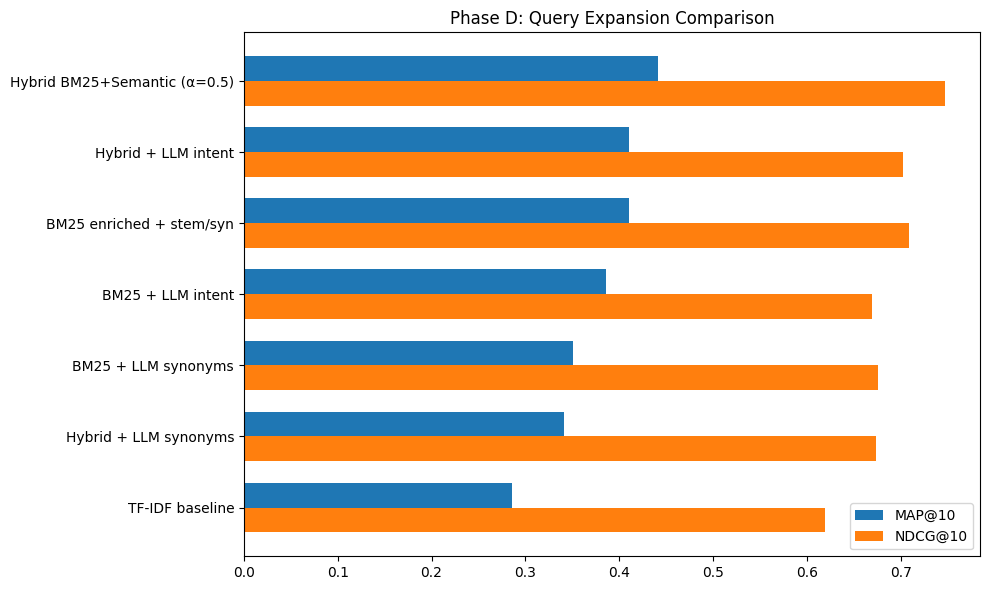

In [23]:
# Phase D comparison chart
import matplotlib.pyplot as plt

d_chart = phase_d_df.sort_values("MAP@10")
y = range(len(d_chart))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y, d_chart["MAP@10"], height=0.35, label="MAP@10", align="edge")
ax.barh([i - 0.35 for i in y], d_chart["NDCG@10"], height=0.35, label="NDCG@10", align="edge")
ax.set_yticks(y)
ax.set_yticklabels(d_chart["Engine"])
ax.set_title("Phase D: Query Expansion Comparison")
ax.legend()
plt.tight_layout()

In [24]:
# D3: Full pipeline — best expansion + cross-encoder reranking
# Test LLM expansion combined with Phase C's reranker
# (CrossEncoder lazy-reloads here after being unloaded in Phase C cleanup)

# LLM-expanded hybrid → cross-encoder rerank
best_d1_hybrid = QueryExpandedSearchEngine(
    engine=hybrid_weighted, expander=llm_expander,
    name_override="Hybrid + LLM synonyms",
)
best_d1_hybrid.fit(product_df)

rerank_d1_ce = ReRankingEngine(
    retriever=best_d1_hybrid,
    reranker=cross_encoder_reranker,
    retrieve_n=100,
    name_override="Hybrid + LLM synonyms + CrossEncoder",
)
rerank_d1_ce.fit(product_df)

# LLM intent-expanded hybrid → cross-encoder rerank
best_d2_hybrid = QueryExpandedSearchEngine(
    engine=hybrid_weighted, expander=intent_expander,
    name_override="Hybrid + LLM intent",
)
best_d2_hybrid.fit(product_df)

rerank_d2_ce = ReRankingEngine(
    retriever=best_d2_hybrid,
    reranker=cross_encoder_reranker,
    retrieve_n=100,
    name_override="Hybrid + LLM intent + CrossEncoder",
)
rerank_d2_ce.fit(product_df)

# Evaluate the full pipelines
full_pipeline_engines = [
    tfidf_baseline,      # TF-IDF baseline
    rerank_hybrid_ce,    # Phase C best (no expansion)
    rerank_d1_ce,        # Phase D1 + C
    rerank_d2_ce,        # Phase D2 + C
]

full_rows = []
for eng in full_pipeline_engines:
    t0 = _time.perf_counter()
    rdf = Evaluator.evaluate_queries(
        engine=eng, product_df=product_df,
        query_df=query_df, label_df=label_df, k=10,
    )
    elapsed = _time.perf_counter() - t0
    full_rows.append({
        "Engine": eng.name,
        "MAP@10": round(rdf["map@k"].mean(), 4),
        "NDCG@10": round(rdf["ndcg@k"].mean(), 4),
        "Time (s)": round(elapsed, 1),
    })

full_pipeline_df = pd.DataFrame(full_rows)
full_pipeline_df

ecom_search.search_engine — Hybrid + LLM synonyms — ready (inner engine already fitted)
ecom_search.search_engine — Hybrid + LLM synonyms + CrossEncoder — ready (retriever already fitted)
ecom_search.search_engine — Hybrid + LLM intent — ready (inner engine already fitted)
ecom_search.search_engine — Hybrid + LLM intent + CrossEncoder — ready (retriever already fitted)
ecom_search.evaluation — TF-IDF baseline — MAP@10: 0.2855 | NDCG@10: 0.6196
httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cross-encoder/ms-marco-MiniLM-L6-v2/c5ee24cb16019beea0893ab7796b1df96625c6b8/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 8240.44it/s]
BertForSeq

,Engine,MAP@10,NDCG@10,Time (s)
0,TF-IDF baseline,0.2855,0.6196,7.3
1,Hybrid + CrossEncoder rerank,0.4704,0.7630,179.2
2,Hybrid + LLM synonyms + CrossEncoder,0.4640,0.7595,211.1
3,Hybrid + LLM intent + CrossEncoder,0.4659,0.7578,185.4


## Prompt 2: Leveraging Partial Matches — NDCG@K

### Problem
The original MAP@10 metric treats labels as binary: a product is either **Exact** (relevant) or irrelevant. This means **Partial** matches — products that are related but not an exact match — are penalized the same as completely irrelevant products. This is overly strict and doesn't reflect real user behavior, where a "partially relevant" result is still useful.

### Solution: Normalized Discounted Cumulative Gain (NDCG@K)

NDCG is the industry-standard metric for **graded relevance** in information retrieval. We assign relevance grades:

| Label | Grade |
|-------|-------|
| Exact | 2 |
| Partial | 1 |
| Irrelevant | 0 |

The formula works in two steps:

**DCG@K** (Discounted Cumulative Gain): sums relevance grades with a logarithmic position discount — higher-ranked results contribute more.

$$DCG@K = \sum_{i=1}^{K} \frac{rel_i}{\log_2(i + 1)}$$

**NDCG@K**: normalizes DCG by the ideal ranking (IDCG), so scores fall in [0, 1]:

$$NDCG@K = \frac{DCG@K}{IDCG@K}$$

### Justification
1. **Credits partial matches proportionally** — a Partial result at rank 1 earns grade 1 instead of 0, reflecting its actual usefulness.
2. **Position-aware** — early results matter more (log discount), matching real user behavior where only top results get clicked.
3. **Industry standard** — NDCG is used by Google, Amazon, and academic IR benchmarks (TREC, MS MARCO).
4. **Available in WANDS** — the dataset provides three-level labels (Exact/Partial/Irrelevant) for all query-product pairs, so we have the graded relevance data NDCG requires.

### Tradeoffs
- **Requires graded labels for all retrieved items** — if a retrieved product has no label in the dataset, we must assume relevance = 0, which could underestimate quality. (In WANDS, all candidate products are labeled, so this is not an issue.)
- **Harder to interpret than MAP** — MAP has a clear "precision" interpretation; NDCG's meaning is less intuitive to non-IR practitioners.
- **Grade assignment is subjective** — the choice of Exact=2, Partial=1 assumes a 2:1 value ratio. Alternative mappings (e.g., Exact=3, Partial=1) would shift scores.

### Implementation
The `Evaluator.ndcg_at_k()` method in `evaluation.py` implements this metric. It is computed alongside MAP@10 for every engine in the comparison above.

In [25]:
# Demonstrate the difference: MAP with Exact+Partial vs Exact-only
# This shows how much the strict binary treatment penalizes the model
result_baseline = Evaluator.evaluate_queries(
    engine=tfidf_baseline,
    product_df=product_df,
    query_df=query_df,
    label_df=label_df,
    k=10,
    label_filter="Exact",
)

result_partial = Evaluator.evaluate_queries(
    engine=tfidf_baseline,
    product_df=product_df,
    query_df=query_df,
    label_df=label_df,
    k=10,
    label_filter="Exact+Partial",
)

print(f"TF-IDF Baseline — MAP@10 (Exact only):       {result_baseline['map@k'].mean():.4f}")
print(f"TF-IDF Baseline — MAP@10 (Exact + Partial):  {result_partial['map@k'].mean():.4f}")
print(f"TF-IDF Baseline — NDCG@10 (graded):          {result_baseline['ndcg@k'].mean():.4f}")
print()
print("The gap between Exact-only MAP and Exact+Partial MAP shows how many")
print("useful partial matches were being discarded by the strict binary metric.")

ecom_search.evaluation — TF-IDF baseline — MAP@10: 0.2855 | NDCG@10: 0.6196
ecom_search.evaluation — TF-IDF baseline — MAP@10: 0.6518 | NDCG@10: 0.6196


TF-IDF Baseline — MAP@10 (Exact only):       0.2855
TF-IDF Baseline — MAP@10 (Exact + Partial):  0.6518
TF-IDF Baseline — NDCG@10 (graded):          0.6196

The gap between Exact-only MAP and Exact+Partial MAP shows how many
useful partial matches were being discarded by the strict binary metric.


## Conclusions & Future Work

**Project note:** This notebook is organized around the **core retrieval-improvement track** (demonstrated MAP improvement), with additional **engineering-track** refactoring included in the codebase architecture.

### Key Findings

| Phase | Best Engine | MAP@10 | NDCG@10 | Δ MAP vs Baseline |
|-------|------------|--------|---------|-------------------|
| Baseline | TF-IDF (name + desc) | 0.2854 | 0.6194 | — |
| A – Lexical | BM25 enriched + stem/syn | 0.4102 | 0.7087 | +43.7 % |
| B – Hybrid | Hybrid BM25+Semantic (α=0.5) | 0.4413 | 0.7472 | +54.6 % |
| C – Re-rank | Hybrid + CrossEncoder rerank | 0.4704 | 0.7630 | +64.8 % |

- The OOP refactor makes it trivial to swap search backends (TF-IDF → BM25 → semantic → hybrid → reranked) without changing evaluation code.
- **Phase A** — Adding more product fields, stemming, and synonyms pushed MAP@10 from 0.29 to 0.41 (+44 %).
- **Phase B** — Fusing BM25 with SentenceTransformer embeddings via min-max score blending or RRF pushed MAP@10 to 0.44 (+55 %). The α-sweep shows the sweet spot is around α ∈ [0.4, 0.6], confirming that both lexical and semantic signals contribute meaningfully.
- **Phase C** — Two-stage re-ranking with a cross-encoder (`ms-marco-MiniLM-L-6-v2`) on top of hybrid retrieval pushed MAP@10 to **0.4704** (+65 % vs baseline). Even on BM25-only first stage, cross-encoder reranking achieved 0.4668, demonstrating the power of joint query-document scoring. Metadata boosting (rating + popularity) had negligible impact (+0.0002 MAP), suggesting the WANDS labels don't correlate with product popularity.
- NDCG@K provides a fairer evaluation than binary MAP by crediting partial matches.

### What I Would Do With More Time & Resources
1. **Learning-to-rank re-ranker** — Train a model (LambdaMART / XGBoost) on the WANDS labels combining retrieval score, cross-encoder score, and product metadata as features.
2. **Query expansion** — Use the `query_class` field to inject category terms into the search query.
3. **Proper train/test split** — Split queries into train/validation/test to avoid overfitting retrieval parameters to the full dataset.
4. **Larger / fine-tuned embedding model** — Fine-tune on WANDS or use a domain-specific model for better e-commerce semantic matching.
5. **Caching & latency optimisation** — Pre-compute embeddings, cache cross-encoder scores for frequent queries, use FAISS/HNSW for approximate nearest neighbour search at scale.